# 05 — Rolling-ball flat-field correction after Fourier filtering

This notebook starts with the current 04 workflow: raw image → brightest-pixel normalization on the full image → confirmed on-MS crop → notch or elliptical Gaussian low-pass filtering. It then estimates a rolling-ball background from the **Fourier-filtered crop** and corrects multiplicative shading.

The current input path and Fourier settings are copied from 04. Enable `USE_DEMO` for synthetic Fourier data; it is not a ground-truth flat-field calibration. Notebook 04 remains independent.

Use the Python 3.12 `qcl` kernel with the project and notebook dependencies installed. The new background estimator uses `scikit-image` (included in project dependencies). Code comments and explanations are in English.


In [2]:
%matplotlib widget

from pathlib import Path
import json
import sys

# Locate the source checkout when launched from the repository or notebooks folder.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src" / "qcl_analysis" / "fourier.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("Open this notebook with its working directory inside qcl-image-analysis.")
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.ndimage import maximum_filter

from qcl_analysis.io import load_qcl_csv
from qcl_analysis.reflectance import calculate_gold_reference, calculate_reflectance
from qcl_analysis.fourier import (
    fourier_spectrum, apply_fourier_notch_filter, apply_fourier_lowpass_filter,
)

import math
from dataclasses import asdict
import ipywidgets as widgets
from matplotlib.widgets import RectangleSelector
from qcl_analysis.roi import ROI
from qcl_analysis.cropping import crop_image

import skimage
from qcl_analysis.flat_field import rolling_ball_flat_field

flat_result = None
flat_source_result = None
flat_comparison_result = None
comparison_result = None


## 1. Choose the input

- `INPUT_PATH`: a single numeric image CSV, or a directory containing image CSVs.
- `FILE_GLOB`: used only for directories. For exported results, point at `reflectance/on_ms` or `reflectance/out_ms`; do not mix QC tables with image arrays. Use `**/*.csv` to search recursively.
- `FILE_INDEX`: selects one image from the sorted file list. Process images individually while tuning.
- `INPUT_KIND`: `"reflectance"` loads values unchanged. Use `"raw"` only for raw MCT intensities; the code then computes `R = I / I_goldref`. Do not normalize an already normalized reflectance image again.
- `N_REFERENCE_PIXELS`: used only for raw input. It is not a Fourier filter parameter.

CSV input must be a finite 2D numeric array without headers, matching the existing project image format.

Raw input is normalized using the brightest pixels of the **full image before cropping**. The crop is not normalized again. Interactive selection requires `ipympl` and `ipywidgets` from the project's notebook dependencies; use the `qcl` kernel and run the setup cell first.


In [8]:
USE_DEMO = False
INPUT_PATH = Path("/Users/ethanjiang/Documents/Cornell/Research/Drug Response/Data/20260907_3T3L1_P10_Trypsin_0.025%_BiResMS_CaF2/QCL/2026-09-08_014/stacks/pattern0")
FILE_GLOB = "*.csv"
# FILE_INDEX = 1 # 1080 Phosphate
FILE_INDEX = 4 # 1658 Amide 1
# FILE_INDEX = 5 
INPUT_KIND = "raw"  # Either "reflectance" or "raw".
N_REFERENCE_PIXELS = 100

# Invalidate prior crops and results when the input is reloaded.
if "on_ms_selector" in globals() and on_ms_selector is not None:
    on_ms_selector.close()
on_ms_selector = None
reflectance = None
result = None
full_reflectance = None
source_path = None
clean_demo = None
if USE_DEMO:
    y, x = np.mgrid[:192, :256]
    clean_demo = (0.55 + 0.12 * np.exp(-((x - 120)**2 + (y - 90)**2) / 1000)
                  + 0.035 * np.cos(2 * np.pi * x / 128))
    grid = (0.045 * np.cos(2 * np.pi * x / 16)
            + 0.035 * np.cos(2 * np.pi * y / 12))
    full_reflectance = clean_demo + grid
else:
    path = INPUT_PATH.expanduser()
    if path.is_file():
        files = [path]
    elif path.is_dir():
        files = sorted(p for p in path.glob(FILE_GLOB) if p.is_file())
    else:
        raise FileNotFoundError(f"Input path does not exist: {path}")
    if not files:
        raise FileNotFoundError(f"No files match {FILE_GLOB} in {path}")
    if not 0 <= FILE_INDEX < len(files):
        raise ValueError(f"FILE_INDEX must be between 0 and {len(files) - 1}.")
    source_path = files[FILE_INDEX]
    print(f"Selected {FILE_INDEX + 1}/{len(files)}: {source_path}")
    image = load_qcl_csv(source_path)
    if INPUT_KIND == "reflectance":
        full_reflectance = image.copy()
    elif INPUT_KIND == "raw":
        gold_reference = calculate_gold_reference(image, N_REFERENCE_PIXELS)
        full_reflectance = calculate_reflectance(image, gold_reference)
        print(f"I_goldref = {gold_reference:.6g}")
    else:
        raise ValueError("INPUT_KIND must be 'reflectance' or 'raw'.")
print(f"Full reflectance shape: {full_reflectance.shape}; range: {full_reflectance.min():.6g} to {full_reflectance.max():.6g}")


Selected 5/6: /Users/ethanjiang/Documents/Cornell/Research/Drug Response/Data/20260907_3T3L1_P10_Trypsin_0.025%_BiResMS_CaF2/QCL/2026-09-08_014/stacks/pattern0/lineScan_1658_0invcm.csv
I_goldref = 4.9623
Full reflectance shape: (226, 325); range: 0.0025616 to 1.002


## 1.1 Select the on-MS region on the full reflectance image

1. Run the next cell and drag a rectangle around the on-MS region.
2. Resize or move it using the rectangle handles. Turn off toolbar pan/zoom before drawing.
3. Click **Confirm on-MS crop**. Then run the following crop cell and all later cells.

The contrast slider changes the display only. Coordinates refer to the full image and follow `[x_min, x_max)` / `[y_min, y_max)` slicing. Each pixel is selected by its center, and the crop must be at least 2 × 2 pixels. The rectangle covers only the on-MS region you choose; it does not need an out-MS or R0 region.

Changing the rectangle invalidates its previous confirmation. After changing the crop or input, rerun the crop, spectrum, filter, comparison and export cells in order. Filtering is blocked until a confirmed crop is available. A **Run All** will stop at the crop cell so you can make the selection.


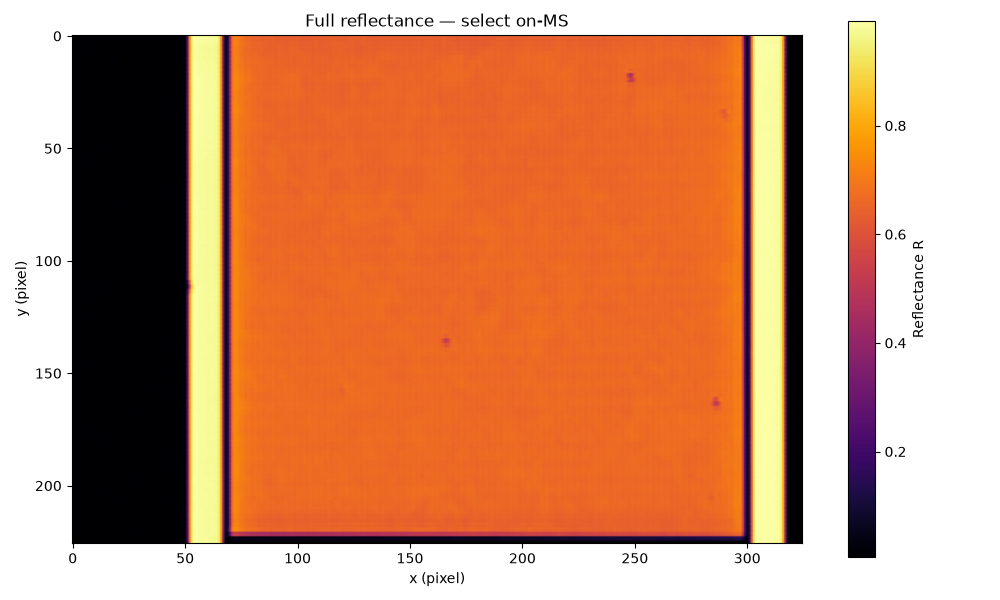

In [9]:
class OnMSCropSelector:
    """Select and confirm one rectangle without modifying full reflectance.

    RectangleSelector reports image coordinates. Pixel-center bounds are
    converted to half-open ROI slices, then the existing crop_image helper
    creates an independent array. Any new selection invalidates that array
    for downstream use until the user confirms and extracts a new crop.
    """

    def __init__(self, image):
        self.image = image
        self.roi = None
        self.confirmed_roi = None
        self.active_crop = None
        self.status = widgets.Label(value="Drag a rectangle around the on-MS region.")
        self.confirm_button = widgets.Button(description="Confirm on-MS crop", button_style="success")
        self.confirm_button.on_click(self._confirm)
        self.contrast = widgets.FloatRangeSlider(
            value=(1, 99), min=0, max=100, step=0.5,
            description="Contrast", continuous_update=False,
        )
        with plt.ioff():
            self.figure, self.ax = plt.subplots(figsize=(10, 6))
        self.artist = self.ax.imshow(image, origin="upper", cmap="inferno")
        self.ax.set(title="Full reflectance — select on-MS", xlabel="x (pixel)", ylabel="y (pixel)")
        self.figure.colorbar(self.artist, ax=self.ax, label="Reflectance R")
        self.selector = RectangleSelector(
            self.ax, self._select, button=[1], useblit=False,
            interactive=True, minspanx=0, minspany=0,
        )
        self.contrast.observe(self._contrast, names="value")
        self._contrast({"new": self.contrast.value})
        self.figure.tight_layout()

    def _contrast(self, change):
        low, high = change["new"]
        if low >= high:
            return
        vmin, vmax = np.percentile(self.image, [low, high])
        self.artist.set_clim(vmin, max(vmax, vmin + 1e-12))
        self.figure.canvas.draw_idle()

    def _select(self, start, end):
        self.confirmed_roi = None
        self.active_crop = None
        self.roi = None
        if any(v is None for v in (start.xdata, start.ydata, end.xdata, end.ydata)):
            self.status.value = "Selection is outside the image. Draw a new rectangle."
            return
        height, width = self.image.shape
        xmin, xmax = sorted((start.xdata, end.xdata))
        ymin, ymax = sorted((start.ydata, end.ydata))
        x0, x1 = max(0, math.ceil(xmin)), min(width, math.floor(xmax) + 1)
        y0, y1 = max(0, math.ceil(ymin)), min(height, math.floor(ymax) + 1)
        if x1 - x0 < 2 or y1 - y0 < 2:
            self.status.value = "Select at least 2 × 2 pixels."
            return
        self.roi = ROI(x0, x1, y0, y1)
        self.status.value = f"Selected x=[{x0}, {x1}), y=[{y0}, {y1}). Click Confirm on-MS crop."

    def _confirm(self, _):
        if self.roi is None:
            self.status.value = "Draw a valid rectangle first."
            return
        self.confirmed_roi = self.roi
        self.active_crop = None
        self.status.value = f"Confirmed {self.roi}. Run the crop cell below, then rerun downstream cells."

    def extract(self):
        if self.confirmed_roi is None:
            raise RuntimeError("Draw an on-MS rectangle and click Confirm on-MS crop first.")
        self.active_crop = crop_image(self.image, self.confirmed_roi)
        return self.active_crop

    def require_current(self, image):
        if self.confirmed_roi is None or self.active_crop is None or image is not self.active_crop:
            raise RuntimeError("Confirm the current on-MS selection and rerun the crop cell first.")

    def show(self):
        display(widgets.VBox([self.contrast, self.confirm_button, self.status]))
        display(self.figure.canvas)

    def close(self):
        self.confirmed_roi = None
        self.active_crop = None
        self.selector.disconnect_events()
        plt.close(self.figure)
        self.confirm_button.close()
        self.contrast.close()
        self.status.close()


# Rerunning this cell starts a fresh selection and invalidates older results.
if on_ms_selector is not None:
    on_ms_selector.close()
reflectance = None
result = None
on_ms_selector = OnMSCropSelector(full_reflectance)
on_ms_selector.show()


## 1.2 Extract and verify the confirmed crop

Run this cell **after clicking Confirm on-MS crop**. `full_reflectance` retains the full normalized image; `reflectance` becomes an independent copy of the selected on-MS region. Every later frequency analysis and filter uses `reflectance`. Plot coordinates below are local to the crop, starting at zero.

Cropping changes the FFT bin spacing and can change spectral peaks arising from boundaries. Reinspect the cropped spectrum before reusing previously chosen notch centers.


on-MS ROI in full-image coordinates: ROI(x_min=87, x_max=285, y_min=8, y_max=213)
Full image: (226, 325); on-MS crop: (205, 198)


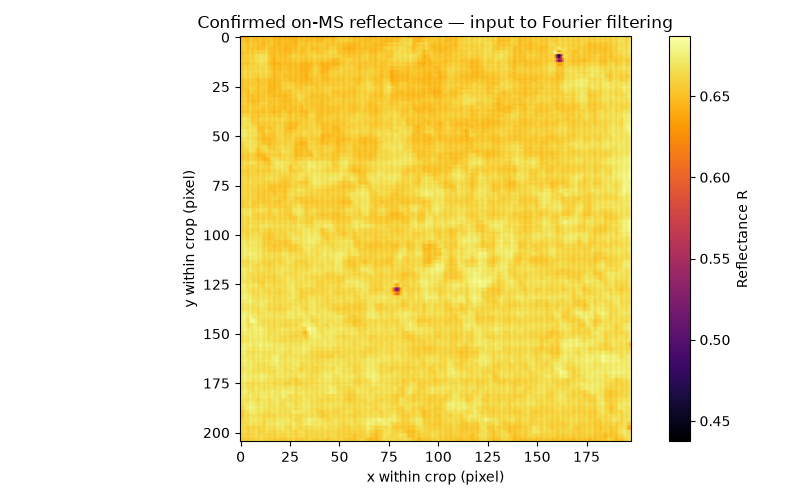

In [24]:
reflectance = on_ms_selector.extract()
on_ms_roi = on_ms_selector.confirmed_roi
result = None
clean_demo_crop = crop_image(clean_demo, on_ms_roi) if USE_DEMO else None
print(f"on-MS ROI in full-image coordinates: {on_ms_roi}")
print(f"Full image: {full_reflectance.shape}; on-MS crop: {reflectance.shape}")
fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(reflectance, origin="upper", cmap="inferno")
ax.set(title="Confirmed on-MS reflectance — input to Fourier filtering",
       xlabel="x within crop (pixel)", ylabel="y within crop (pixel)")
fig.colorbar(im, ax=ax, label="Reflectance R")
plt.tight_layout()
plt.show()


## 2. Inspect the image and spatial-frequency peaks

Frequency axes use **cycles/pixel**, not the QCL infrared wavenumber in cm⁻¹. A frequency of `0.0625` corresponds to a period of `1 / 0.0625 = 16` pixels.

- Vertical stripes vary along x: look near `(fy, fx) = (0, ±1/period_x)`.
- Horizontal stripes vary along y: look near `(±1/period_y, 0)`.
- Oblique stripes give off-axis peaks. Their frequency vector is perpendicular to the stripes; their period is `1 / sqrt(fy² + fx²)`.
- Real-valued images have paired peaks at `(fy, fx)` and `(-fy, -fx)`. Enter only one; the filter adds its partner.
- Narrow grid lines can produce additional harmonics. Add observed harmonic peaks separately.

`INSPECTION_WINDOW=True` subtracts the mean and applies a Hann window **only to the inspection spectrum** to reduce edge leakage. It does not alter the image used for filtering. The candidate table is a convenience for inspection, not an automatic classification of noise: real specimen structures also create peaks.

FFT conventions follow the [NumPy FFT documentation](https://numpy.org/doc/stable/reference/routines.fft.html).

,peak,fy,fx,period_pixels,FFT_amplitude
0,1,0.000000,0.368687,2.712329,18.725225
1,2,0.131707,0.000000,7.592593,10.771318
2,3,0.024390,-0.030303,25.707386,6.370179
3,4,0.019512,0.040404,22.287185,5.222319
4,5,0.043902,0.035354,17.740715,4.332113
5,6,0.004878,-0.040404,24.571568,4.077074
6,7,0.043902,-0.005051,22.628536,3.674011
7,8,0.048780,-0.055556,13.525924,3.339996
8,9,0.024390,-0.095960,10.099914,3.301988
9,10,0.019512,0.085859,11.357462,3.272953


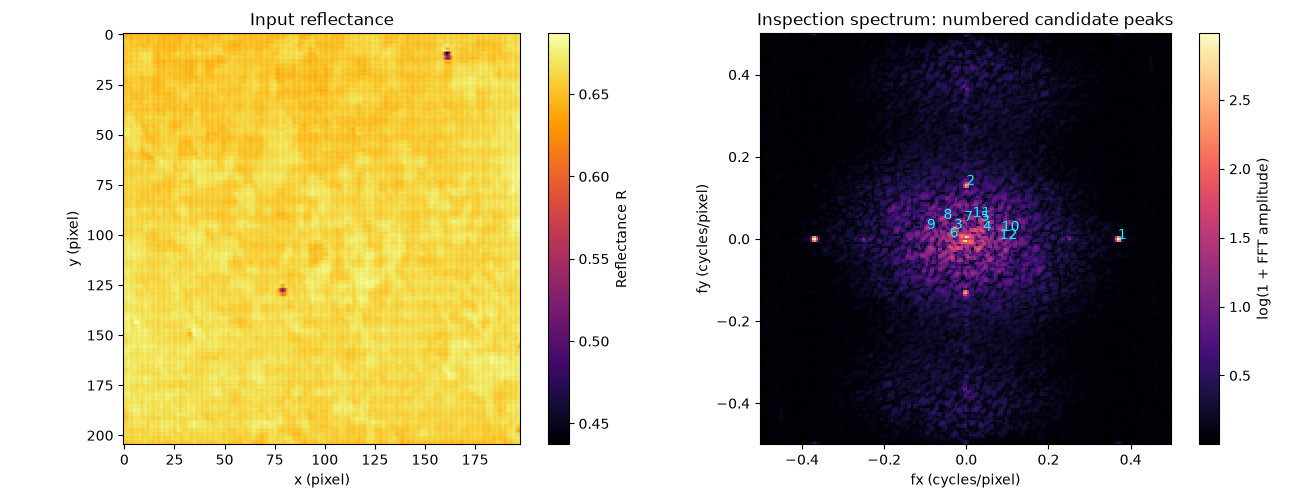

In [25]:
on_ms_selector.require_current(reflectance)

INSPECTION_WINDOW = True
CANDIDATE_MIN_FREQUENCY = 0.025
CANDIDATE_COUNT = 12

spectrum, fy, fx = fourier_spectrum(reflectance, window=INSPECTION_WINDOW)
power = np.abs(spectrum)
FY, FX = np.meshgrid(fy, fx, indexing="ij")
# Retain one half-plane, excluding the low-frequency central region.
candidates = ((power == maximum_filter(power, size=5, mode="wrap"))
              & (np.hypot(FY, FX) > CANDIDATE_MIN_FREQUENCY)
              & ((FY > 0) | ((FY == 0) & (FX > 0))))
positions = np.argwhere(candidates)
order = np.argsort(power[candidates])[::-1][:CANDIDATE_COUNT]
rows = []
for rank, (iy, ix) in enumerate(positions[order], start=1):
    rows.append({"peak": rank, "fy": fy[iy], "fx": fx[ix],
                 "period_pixels": 1 / np.hypot(fy[iy], fx[ix]),
                 "FFT_amplitude": power[iy, ix]})
display(pd.DataFrame(rows))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im = axes[0].imshow(reflectance, cmap="inferno", origin="upper")
axes[0].set(title="Input reflectance", xlabel="x (pixel)", ylabel="y (pixel)")
fig.colorbar(im, ax=axes[0], label="Reflectance R")
im = axes[1].pcolormesh(fx, fy, np.log1p(power), shading="auto", cmap="magma")
for row in rows:
    axes[1].annotate(str(row["peak"]), (row["fx"], row["fy"]), color="cyan")
axes[1].set(title="Inspection spectrum: numbered candidate peaks",
            xlabel="fx (cycles/pixel)", ylabel="fy (cycles/pixel)", aspect="equal")
fig.colorbar(im, ax=axes[1], label="log(1 + FFT amplitude)")
plt.tight_layout()
plt.show()


## 3. Select and adjust the filter

Set `FILTER_MODE` to `"notch"` (existing paired Gaussian notches) or `"lowpass"` (elliptical 2D Gaussian low-pass). Both modes start from the **same original on-MS crop**; switching modes does not filter an already filtered image. Rerun this cell and Sections 4–5 after changing the mode or parameters.

- **Notch:** suppress selected artifact peaks while retaining other frequencies.
- **Low-pass:** smoothly attenuate high spatial frequencies in all directions. No peak selection is required, but cell boundaries and fine structure are also smoothed. Inspect the removed image to judge this tradeoff.

### Elliptical low-pass parameters

`LOWPASS_CUTOFF_X` and `LOWPASS_CUTOFF_Y` independently control the frequency-mask width along **fx (horizontal)** and **fy (vertical)**. Units are **cycles/pixel**, and each value must satisfy `0 < cutoff <= 0.5`.

$$H(f_y,f_x)=\exp\left[-\ln(2)\left(\frac{f_x^2}{c_x^2}+\frac{f_y^2}{c_y^2}\right)\right].$$

The **50% amplitude transmission contour** is an ellipse with semi-axes `c_x` and `c_y`; its full x/y widths are `2*c_x` and `2*c_y`. These are smooth Gaussian widths, not a hard elliptical boundary or -3 dB cutoffs.

| Parameter | Effect |
|---|---|
| `LOWPASS_CUTOFF_X` | Smaller values suppress variation along image x more strongly, including vertical stripes. |
| `LOWPASS_CUTOFF_Y` | Smaller values suppress variation along image y more strongly, including horizontal stripes. |
| Equal x/y cutoffs | Recover the previous circular Gaussian mask. |

For example, `LOWPASS_CUTOFF_X = 0.08` and `LOWPASS_CUTOFF_Y = 0.20` create a frequency ellipse that is narrower horizontally and taller vertically, giving stronger smoothing along image x. At `(fx, fy)=(c_x, 0)` or `(0, c_y)`, amplitude transmission is 0.5; at `(c_x, c_y)` it is 0.25. A 10-pixel x period has 50% transmission when `c_x=0.1` and `fy=0`.

Only these two cutoffs, `PAD_PIXELS` and `PRESERVE_MEAN` affect low-pass mode. Notch parameters are inactive. Both modes preserve DC; low-pass does not use the notch mode's protected disk. Smaller cutoffs also remove more real cell-edge and texture information. The ellipse is aligned with the x/y axes, with no rotation parameter.

### Notch parameters and shared settings

| Parameter | Meaning | How to adjust |
|---|---|---|
| `NOTCH_CENTERS` | List of `(fy, fx)` peak coordinates in cycles/pixel. Negative partners are automatic. | Copy confirmed grid peaks from the spectrum/table. `[]` means no filtering. Never select the central DC peak. |
| `SIGMA` | Gaussian notch standard deviation in cycles/pixel; full width at half maximum ≈ `2.355 * SIGMA`. | Start narrow, around 1–2 frequency bins (`1 / height` vertically, `1 / width` horizontally). Increase only if artifact peaks are broad. |
| `STRENGTH` | Maximum fractional attenuation: `0` = unchanged, `0.9` = 90% attenuation at a center, `1` = full rejection at a center. | Start below 1 and increase while examining the removed image. Off-bin centers may not reach the exact requested depth. |
| `PROTECT_RADIUS` | Circular low-frequency region passed unchanged, in cycles/pixel. DC is always preserved. | Protect broad specimen structure; centers must lie outside this radius. Keep notch tails away from its hard boundary. |
| `PAD_PIXELS` | Reflection padding on every edge, removed after inverse FFT. `0` uses the original array directly. | Compare 0 with e.g. 32 if edge artifacts appear. Padding changes peak shapes; inspect the actual filter spectra below. |
| `PRESERVE_MEAN` | Restore the original global mean after removing padding. | Usually keep `True` for reflectance. This does not preserve local R0 ROI means. |

The filter uses the strongest Gaussian rejection at each frequency when notches overlap, so duplicate centers do not compound their depth. In notch mode, no general low-pass is applied.

**For your own data:** fill `NOTCH_CENTERS` after inspection, then rerun this cell and the following cells. Changing the input requires rerunning from Section 1. Example: a 16-pixel x period and a 12-pixel y period correspond to `[(0, 1/16), (1/12, 0)]`; these are demonstration values, not a prescription for experimental data.

In [36]:
on_ms_selector.require_current(reflectance)

# Select one independent filtering method for the original on-MS crop.
FILTER_MODE = "notch"  # "notch" or "lowpass".
# FILTER_MODE = "lowpass"  # "notch" or "lowpass".
LOWPASS_CUTOFF_X = 0.25  # Half-amplitude width along fx (cycles/pixel).
LOWPASS_CUTOFF_Y = 0.05  # Half-amplitude width along fy (cycles/pixel).

# These four parameters are used only in notch mode.
NOTCH_CENTERS = [(0.0, 1 / 16), (1 / 12, 0.0)] if USE_DEMO else [(0.0, 0.368182), (0.0, -0.368182), (0.132420, 0.0), (-0.132420, 0.0)]
SIGMA = 0.01
STRENGTH = 0.90
PROTECT_RADIUS = 0.02
# Shared settings for both modes.
PAD_PIXELS = 0
PRESERVE_MEAN = True

# Invalidate older results before validating or applying new settings.
result = None
filter_input = None
if FILTER_MODE == "notch":
    if not NOTCH_CENTERS:
        print("No notch centers selected: output is unchanged. Select artifact peaks above.")
    result = apply_fourier_notch_filter(
        reflectance, NOTCH_CENTERS, sigma=SIGMA, strength=STRENGTH,
        protect_radius=PROTECT_RADIUS, pad_pixels=PAD_PIXELS,
        preserve_mean=PRESERVE_MEAN,
    )
    applied_filter_parameters = {
        "mode": "notch", "notch_centers_fy_fx": [list(p) for p in NOTCH_CENTERS],
        "sigma": SIGMA, "strength": STRENGTH, "protect_radius": PROTECT_RADIUS,
    }
elif FILTER_MODE == "lowpass":
    result = apply_fourier_lowpass_filter(
        reflectance, cutoff_x=LOWPASS_CUTOFF_X, cutoff_y=LOWPASS_CUTOFF_Y,
        pad_pixels=PAD_PIXELS,
        preserve_mean=PRESERVE_MEAN,
    )
    applied_filter_parameters = {
        "mode": "lowpass", "family": "gaussian", "mask_shape": "ellipse",
        "cutoff_x": LOWPASS_CUTOFF_X, "cutoff_y": LOWPASS_CUTOFF_Y,
        "cutoff_definition": "half amplitude (H=0.5)",
    }
else:
    raise ValueError("FILTER_MODE must be 'notch' or 'lowpass'.")
applied_filter_parameters.update({
    "pad_pixels": PAD_PIXELS, "preserve_mean": PRESERVE_MEAN,
    "frequency_units": "cycles/pixel",
})
print(f"Applied filter: {applied_filter_parameters}")
filtered_reflectance = result.filtered
print(f"FFT bin spacing: fy={1 / len(result.fy):.6g}, fx={1 / len(result.fx):.6g} cycles/pixel")

filter_input = reflectance


Applied filter: {'mode': 'notch', 'notch_centers_fy_fx': [[0.0, 0.368182], [0.0, -0.368182], [0.13242, 0.0], [-0.13242, 0.0]], 'sigma': 0.01, 'strength': 0.9, 'protect_radius': 0.02, 'pad_pixels': 0, 'preserve_mean': True, 'frequency_units': 'cycles/pixel'}
FFT bin spacing: fy=0.00487805, fx=0.00505051 cycles/pixel


## 4. Compare output, removed signal and actual filtering spectrum

Original and filtered images share the same display limits. The removed image has a separate zero-centered scale. `DISPLAY_PERCENTILES` changes only image contrast; it never clips stored arrays. Both spectra below share a scale and show the actual padded, unwindowed transform used by the filter. A mask value of 1 passes a frequency; 0 removes it.

Look for loss of cell boundaries or textures in the removed image. Negative output is retained and reported rather than silently clipped. If filtered reflectance is later converted to absorbance, recompute R0 from the filtered reference ROI consistently and compare with the unfiltered analysis.

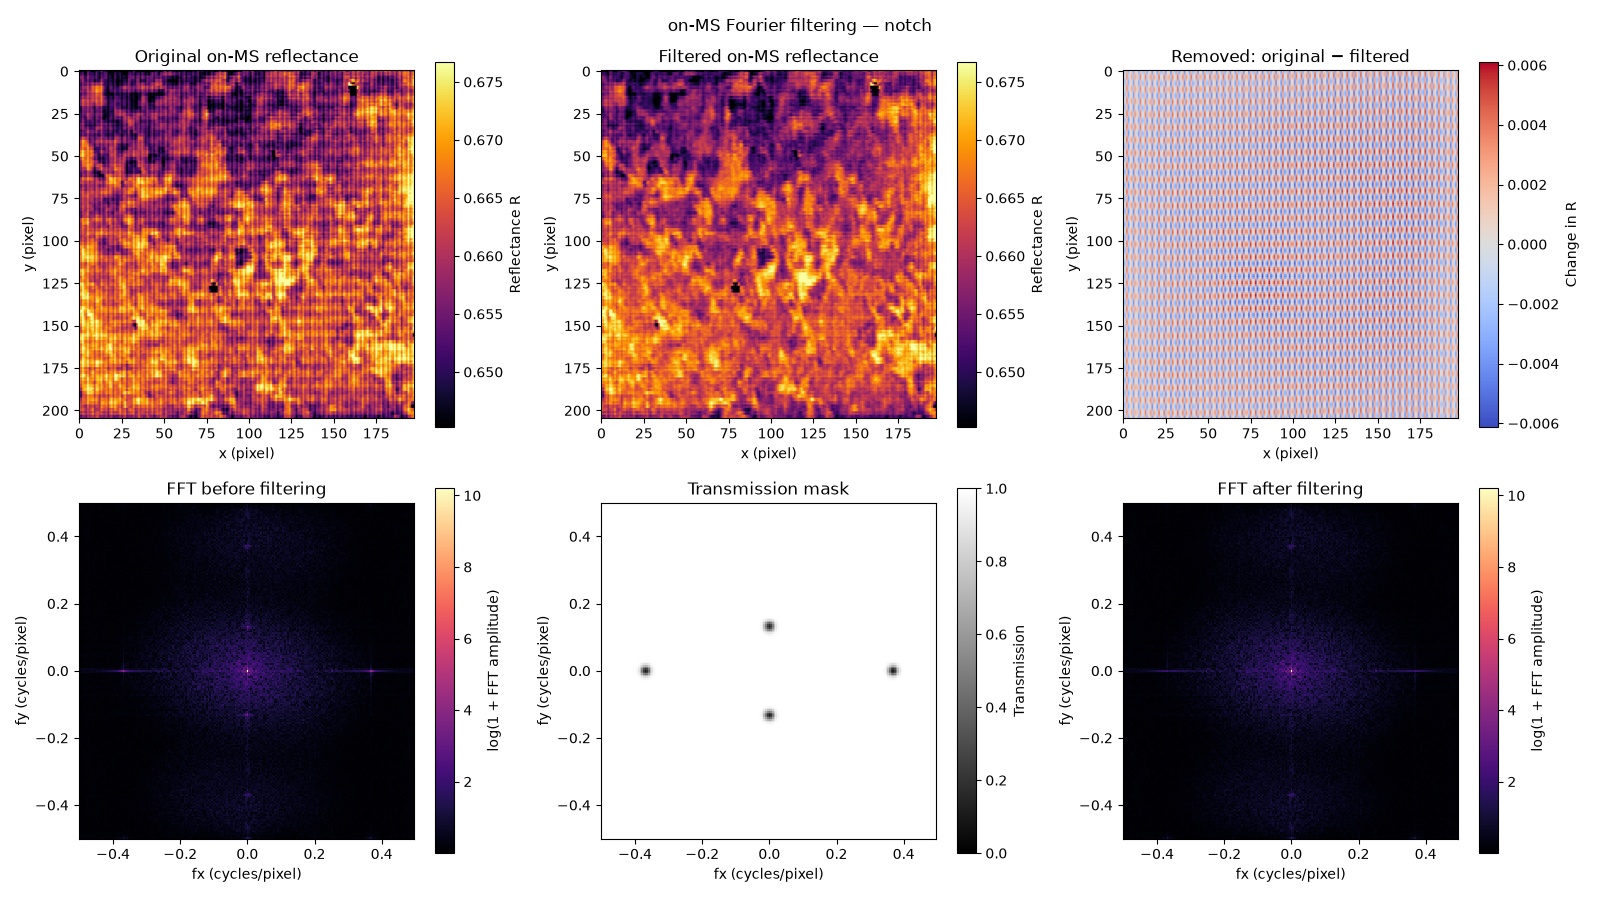

,image,mean,std,min,max,nonpositive_pixels
0,original,0.661674,0.007543,0.437345,0.686819,0
1,filtered,0.661674,0.006889,0.436092,0.687006,0


RMS removed signal: 0.00265685


In [38]:
on_ms_selector.require_current(reflectance)
if result is None or filter_input is not reflectance:
    raise RuntimeError("Rerun the filter cell for the current crop first.")

DISPLAY_PERCENTILES = (1, 99)
vmin, vmax = np.percentile(reflectance, DISPLAY_PERCENTILES)
if vmax <= vmin:
    vmax = vmin + 1e-12
removed_limit = max(float(np.max(np.abs(result.removed))), 1e-12)
log_before = np.log1p(np.abs(result.spectrum_before))
log_after = np.log1p(np.abs(result.spectrum_after))
smin, smax = float(log_before.min()), float(log_before.max())
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, array, title in zip(axes[0],
        [reflectance, filtered_reflectance, result.removed],
        ["Original on-MS reflectance", "Filtered on-MS reflectance", "Removed: original − filtered"]):
    removed_panel = ax is axes[0, 2]
    im = ax.imshow(array, origin="upper", cmap="coolwarm" if removed_panel else "inferno",
                   vmin=-removed_limit if removed_panel else vmin,
                   vmax=removed_limit if removed_panel else vmax)
    ax.set(title=title, xlabel="x (pixel)", ylabel="y (pixel)")
    fig.colorbar(im, ax=ax, label="Reflectance R" if not removed_panel else "Change in R")
for ax, array, title in zip(axes[1],
        [log_before, result.mask, log_after],
        ["FFT before filtering", "Transmission mask", "FFT after filtering"]):
    mask_panel = ax is axes[1, 1]
    im = ax.pcolormesh(result.fx, result.fy, array, shading="auto",
                       cmap="gray" if mask_panel else "magma",
                       vmin=0 if mask_panel else smin, vmax=1 if mask_panel else smax)
    ax.set(title=title, xlabel="fx (cycles/pixel)", ylabel="fy (cycles/pixel)", aspect="equal")
    fig.colorbar(im, ax=ax, label="Transmission" if mask_panel else "log(1 + FFT amplitude)")
fig.suptitle(f"on-MS Fourier filtering — {applied_filter_parameters['mode']}")
plt.tight_layout()
comparison_figure = fig
plt.show()

metrics = pd.DataFrame([
    {"image": name, "mean": array.mean(), "std": array.std(),
     "min": array.min(), "max": array.max(), "nonpositive_pixels": int((array <= 0).sum())}
    for name, array in [("original", reflectance), ("filtered", filtered_reflectance)]
])
display(metrics)
print(f"RMS removed signal: {np.sqrt(np.mean(result.removed**2)):.6g}")
if USE_DEMO:
    before_rmse = np.sqrt(np.mean((reflectance - clean_demo_crop)**2))
    after_rmse = np.sqrt(np.mean((filtered_reflectance - clean_demo_crop)**2))
    print(f"Known-clean demo RMSE: {before_rmse:.6g} → {after_rmse:.6g}")

comparison_result = result


## 5. Estimate the rolling-ball field and correct the filtered image

Let $R_F$ be the Fourier-filtered on-MS reflectance and $B$ its estimated background. This notebook uses **division-based flat-field correction**:

$$R_{\mathrm{corrected}}(x,y)=R_F(x,y)\frac{B_{\mathrm{ref}}}{B(x,y)}.$$

`B_ref` defaults to the median of valid background pixels. This keeps a representative reflectance level; it does not force the original mean. This is not background subtraction (`R_F - B`), and the background is estimated from the sample itself rather than a measured blank field. Real broad specimen structure may be mistaken for illumination. No dark-frame correction is inferred or applied.

The rolling ball uses a circular spatial support and an independently scaled intensity cap. This is important for normalized floating-point reflectance: a ball height of tens of intensity units would be inappropriate. See the [scikit-image rolling-ball example](https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_rolling_ball.html) for background polarity and floating-point scaling.

| Parameter | Meaning and adjustment |
|---|---|
| `RB_RADIUS` | Spatial radius in pixels, integer ≥ 1. Start larger than the radius of features you want to retain. Increase to bridge larger cells; too large can miss illumination variation and costs more time. |
| `RB_KERNEL_HEIGHT` | Ball-cap height in **reflectance units**, positive. Smaller heights make a flatter cap that bridges more intensity variation; larger heights follow local structure more closely. Tune together with radius. `0.05` is a starting value, not an automatically fitted value. |
| `RB_FEATURE_POLARITY` | `"dark"` for dark cells/features on a brighter background (upper-envelope estimate); `"bright"` for bright features on a darker background (lower-envelope estimate). Dark mode internally inverts and then restores the image scale. |
| `RB_SMOOTH_SIGMA` | Gaussian pre-smoothing sigma in pixels **only for field estimation**. 0 disables it. The corrected numerator remains the Fourier-filtered image, without this extra smoothing. |
| `RB_PAD_PIXELS` | Optional reflection padding before rolling ball, removed afterward. 0 uses the library's native edge handling. Compare boundary behavior when changing it. |
| `MIN_BACKGROUND` | Absolute positive divisor threshold in reflectance units. Pixels with nonfinite or ≤ threshold background become NaN and are counted; background is never silently floored. |
| `REFERENCE_LEVEL` | `None` uses median valid background. Set a positive number to impose the same reference scale across multiple images. |

The starting polarity is `"dark"` for dark features in reflectance. Inspect your image and change it when appropriate. Foreground objects should not dominate the estimated background. Changing crop or Fourier parameters requires rerunning Fourier filtering, this cell, the comparisons and export. Every run starts from the current Fourier result; corrections never accumulate.


In [46]:
on_ms_selector.require_current(reflectance)
if result is None or filter_input is not reflectance:
    raise RuntimeError("Run Fourier filtering for the current crop first.")

RB_RADIUS = 200
RB_KERNEL_HEIGHT = 0.05
RB_FEATURE_POLARITY = "dark"  # "dark" or "bright" specimen features.
RB_SMOOTH_SIGMA = 1.0
RB_PAD_PIXELS = 0
MIN_BACKGROUND = 1e-6
REFERENCE_LEVEL = None

# Invalidate older corrections before trying new settings.
flat_result = None
flat_source_result = None
flat_result = rolling_ball_flat_field(
    result.filtered, radius=RB_RADIUS, kernel_height=RB_KERNEL_HEIGHT,
    feature_polarity=RB_FEATURE_POLARITY, smooth_sigma=RB_SMOOTH_SIGMA,
    pad_pixels=RB_PAD_PIXELS, min_background=MIN_BACKGROUND,
    reference_level=REFERENCE_LEVEL,
)
flat_source_result = result
flat_corrected_reflectance = flat_result.corrected
applied_flat_parameters = {
    "method": "rolling_ball", "correction": "divide",
    "formula": "corrected = fourier_filtered * reference_level / background",
    "radius_pixels": RB_RADIUS, "kernel_height_reflectance": RB_KERNEL_HEIGHT,
    "feature_polarity": RB_FEATURE_POLARITY, "smooth_sigma_pixels": RB_SMOOTH_SIGMA,
    "pad_pixels": RB_PAD_PIXELS, "min_background": MIN_BACKGROUND,
    "reference_level_requested": REFERENCE_LEVEL,
    "reference_level_used": flat_result.reference_level,
    "invalid_background_pixels": int((~flat_result.valid_mask).sum()),
    "input_stage": "Fourier-filtered on-MS crop",
}
print(f"Background range: {flat_result.background.min():.6g} to {flat_result.background.max():.6g}")
print(f"Reference level: {flat_result.reference_level:.6g}")
print(f"Invalid background pixels: {(~flat_result.valid_mask).sum()} / {flat_result.valid_mask.size}")


Background range: 0.667888 to 0.680534
Reference level: 0.677374
Invalid background pixels: 0 / 40590


## 6. Review the estimated background and corrected reflectance

Input, background and corrected reflectance share display limits derived from the input and corrected arrays. Gain and change have separate scales. These display settings never change stored values. Inspect whether cells leak into the background estimate, whether boundaries create artifacts, and whether correction enhances noise.

Column medians show spatial trends but are **not proof of correct calibration**: true biological structure also changes those profiles. The correction assumes predominantly multiplicative shading. If absorbance is calculated later, recompute R0 consistently from corrected reference pixels and compare with the uncorrected workflow.


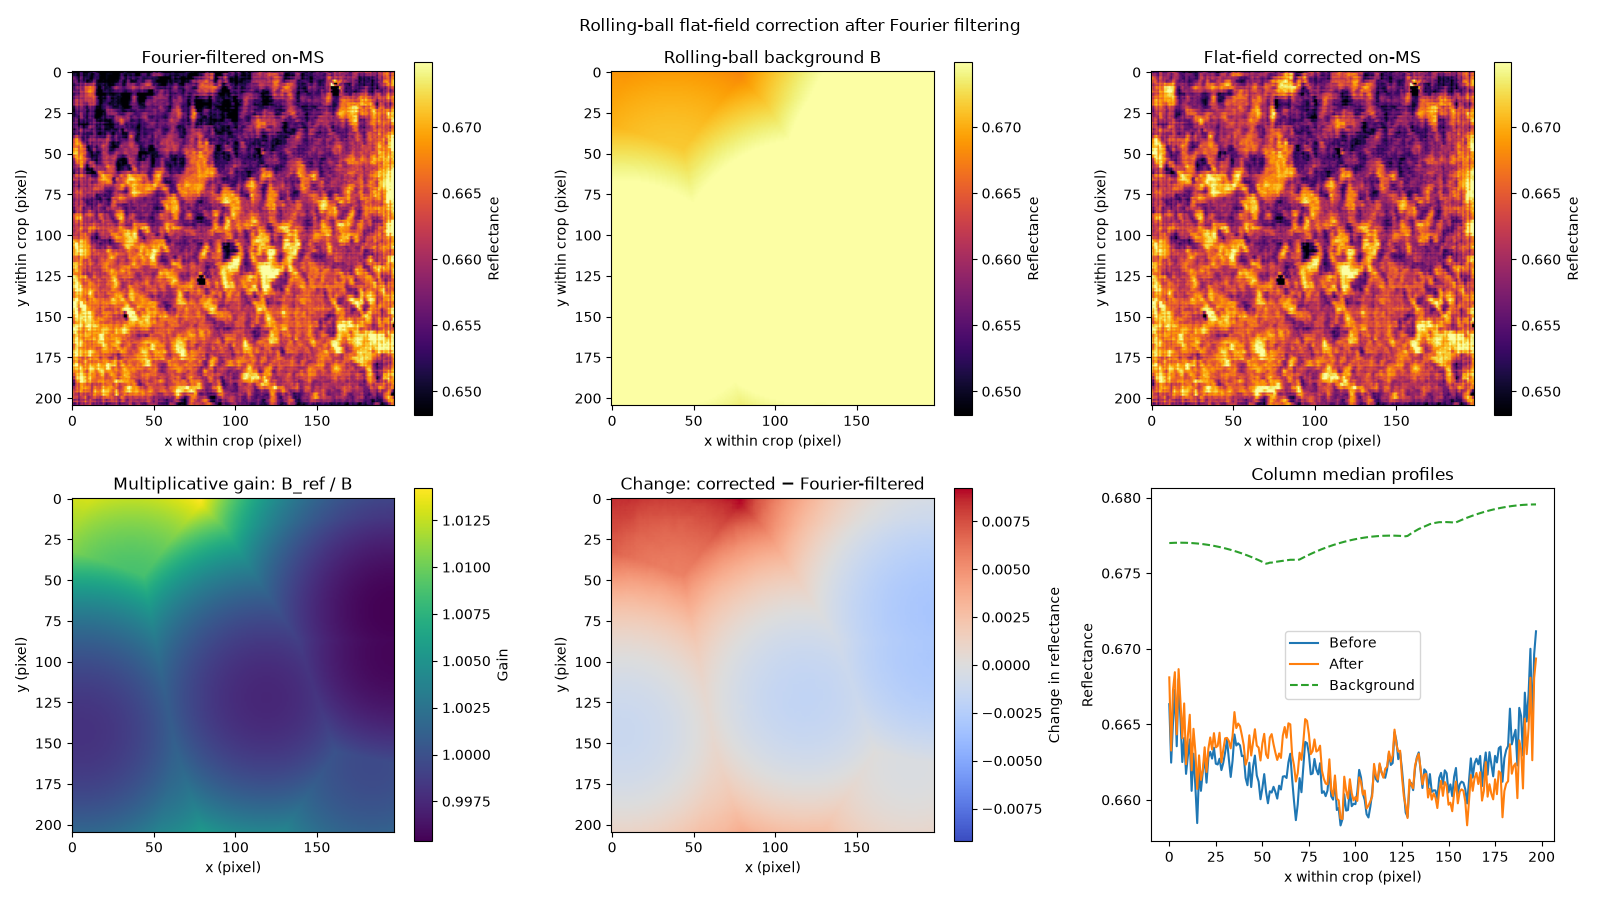

,stage,mean,std,min,max,nonfinite_pixels,nonpositive_pixels
0,Fourier-filtered,0.661674,0.006889,0.436092,0.687006,0,0
1,background,0.676672,0.002681,0.667888,0.680534,0,0
2,corrected,0.662358,0.006153,0.436006,0.685696,0,0


In [47]:
on_ms_selector.require_current(reflectance)
if flat_result is None or flat_source_result is not result or filter_input is not reflectance:
    raise RuntimeError("Rerun flat-field correction for the current Fourier result first.")

FLAT_DISPLAY_PERCENTILES = (1, 99)
finite = np.concatenate([result.filtered.ravel(), flat_result.corrected[flat_result.valid_mask]])
vmin, vmax = np.percentile(finite, FLAT_DISPLAY_PERCENTILES)
vmax = max(vmax, vmin + 1e-12)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, array, title in zip(axes[0],
        [result.filtered, flat_result.background, flat_result.corrected],
        ["Fourier-filtered on-MS", "Rolling-ball background B", "Flat-field corrected on-MS"]):
    im = ax.imshow(array, origin="upper", cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set(title=title, xlabel="x within crop (pixel)", ylabel="y within crop (pixel)")
    fig.colorbar(im, ax=ax, label="Reflectance")
im = axes[1, 0].imshow(flat_result.gain, origin="upper", cmap="viridis")
axes[1, 0].set(title="Multiplicative gain: B_ref / B", xlabel="x (pixel)", ylabel="y (pixel)")
fig.colorbar(im, ax=axes[1, 0], label="Gain")
limit = max(float(np.nanmax(np.abs(flat_result.change))), 1e-12)
im = axes[1, 1].imshow(flat_result.change, origin="upper", cmap="coolwarm", vmin=-limit, vmax=limit)
axes[1, 1].set(title="Change: corrected − Fourier-filtered", xlabel="x (pixel)", ylabel="y (pixel)")
fig.colorbar(im, ax=axes[1, 1], label="Change in reflectance")
axes[1, 2].plot(np.median(result.filtered, axis=0), label="Before")
axes[1, 2].plot(np.nanmedian(flat_result.corrected, axis=0), label="After")
axes[1, 2].plot(np.median(flat_result.background, axis=0), label="Background", linestyle="--")
axes[1, 2].set(title="Column median profiles", xlabel="x within crop (pixel)", ylabel="Reflectance")
axes[1, 2].legend()
fig.suptitle("Rolling-ball flat-field correction after Fourier filtering")
plt.tight_layout()
flat_comparison_figure = fig
plt.show()

flat_summary = pd.DataFrame([
    {"stage": name, "mean": np.nanmean(array), "std": np.nanstd(array),
     "min": np.nanmin(array), "max": np.nanmax(array),
     "nonfinite_pixels": int((~np.isfinite(array)).sum()),
     "nonpositive_pixels": int((array <= 0).sum())}
    for name, array in [("Fourier-filtered", result.filtered),
                        ("background", flat_result.background), ("corrected", flat_result.corrected)]
])
display(flat_summary)
flat_comparison_result = flat_result


## 7. Optional combined export

Set `EXPORT = True` after reviewing both processing stages. A new timestamped directory contains the original on-MS crop, Fourier output and mask, rolling-ball background, gain, corrected image, change, validity mask, summary and both comparison figures. Metadata records crop coordinates and snapshots of the applied Fourier and flat-field settings. The source image and notebook 04 are not overwritten. Only the current crop is exported.


In [ ]:
on_ms_selector.require_current(reflectance)
if result is None or filter_input is not reflectance:
    raise RuntimeError("Rerun Fourier filtering for the current crop first.")
if flat_result is None or flat_source_result is not result:
    raise RuntimeError("Rerun flat-field correction for the current Fourier result first.")

EXPORT = False
OUTPUT_ROOT = ROOT / "outputs" / "flat_field_correction"
if EXPORT:
    if comparison_result is not result or flat_comparison_result is not flat_result:
        raise RuntimeError("Rerun both comparison cells before exporting.")
    from datetime import datetime
    output_dir = OUTPUT_ROOT / datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    output_dir.mkdir(parents=True, exist_ok=False)
    arrays = {
        "original_on_ms_reflectance": reflectance,
        "fourier_filtered_reflectance": result.filtered,
        "fourier_removed_component": result.removed,
        "fourier_mask": result.mask,
        "rolling_ball_background": flat_result.background,
        "flat_field_gain": flat_result.gain,
        "flat_field_corrected_reflectance": flat_result.corrected,
        "flat_field_change": flat_result.change,
        "valid_background_mask": flat_result.valid_mask.astype(int),
    }
    for name, array in arrays.items():
        np.savetxt(output_dir / f"{name}.csv", array, delimiter=",")
    metadata = {
        "source": str(source_path) if source_path else "synthetic_demo",
        "input_kind": "synthetic_reflectance" if USE_DEMO else INPUT_KIND,
        "n_reference_pixels": N_REFERENCE_PIXELS if not USE_DEMO and INPUT_KIND == "raw" else None,
        "normalization_scope": "full image before cropping" if not USE_DEMO and INPUT_KIND == "raw" else "not applied",
        "full_image_shape": list(full_reflectance.shape), "on_ms_shape": list(reflectance.shape),
        "on_ms_roi": asdict(on_ms_roi),
        "roi_coordinates": "full-image pixels; upper bounds exclusive",
        "filter": applied_filter_parameters, "flat_field": applied_flat_parameters,
        "fft_shape": list(result.mask.shape), "mask_order": "fftshift",
        "numpy_version": np.__version__, "skimage_version": skimage.__version__,
    }
    (output_dir / "parameters.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    flat_summary.to_csv(output_dir / "flat_field_summary.csv", index=False)
    comparison_figure.savefig(output_dir / "fourier_comparison.png", dpi=160, bbox_inches="tight")
    flat_comparison_figure.savefig(output_dir / "flat_field_comparison.png", dpi=160, bbox_inches="tight")
    print(f"Exported to: {output_dir}")
else:
    print("Export disabled. Set EXPORT = True after reviewing the result.")
